In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'
from barplot_brackets import *

# LOAD METRICS


In [3]:
# Load Dutta Data
results_path = os.path.join("spikes", "all_networks_metrics_dutta.csv")

if os.path.exists(results_path):
    dutta_df = pd.read_csv(results_path)
    print(f"Loaded {len(dutta_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in dutta_df.columns:
        dutta_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", dutta_df.columns.tolist())
    print("Threshold:", sorted(dutta_df["Threshold"].unique()))
    
    display(dutta_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 78 rows from spikes\all_networks_metrics_dutta.csv
Columns: ['Session', 'Channel', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


,Session,Channel,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-24_17-38-17,13,3.0,11,564,4,0.019130,0.733333,0.037288,35.321212,577,15
1,2025-09-24_16-29-07,5,3.0,25,497,15,0.047893,0.625000,0.088968,9.848000,528,40
2,2025-09-22_17-55-26,26,3.0,130,251,55,0.341207,0.702703,0.459364,16.261795,385,185
3,2025-09-23_15-50-26,28,3.0,94,333,45,0.220141,0.676259,0.332155,11.527305,430,139
4,2025-09-24_10-24-40,30,3.0,57,502,35,0.101968,0.619565,0.175115,16.625731,564,92


In [4]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplenet.csv")

if os.path.exists(results_path):
    rippleNet_df = pd.read_csv(results_path)
    print(f"Loaded {len(rippleNet_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in rippleNet_df.columns:
        rippleNet_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", rippleNet_df.columns.tolist())
    print("Threshold:", sorted(rippleNet_df["Threshold"].unique()))
    
    display(rippleNet_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 1092 rows from spikes\all_networks_metrics_ripplenet.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed123,78,178,31,0.304688,0.715596,0.427397,35.347436,269,109
1,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed456,78,158,31,0.330508,0.715596,0.452174,34.717949,244,109
2,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_best_random_seed789,77,189,32,0.289474,0.706422,0.410667,30.353680,277,109
3,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed123,66,99,43,0.400000,0.605505,0.481752,40.259091,171,109
4,2025-09-22_17-42-27,24,0.3,ripplenet_bidirectional_random_seed456,80,180,29,0.307692,0.733945,0.433604,32.437917,271,109


In [5]:
# Load RipplAI Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    ripplAI_df = pd.read_csv(results_path)
    print(f"Loaded {len(ripplAI_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in ripplAI_df.columns:
        ripplAI_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
    
    ripplAI_df['Model'] = ripplAI_df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)

    print("Columns:", ripplAI_df.columns.tolist())
    print("Threshold:", sorted(ripplAI_df["Threshold"].unique()))
    
    display(ripplAI_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2925 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-22_17-42-27,24,0.1,CNN1D,96,256,13,0.272727,0.880734,0.416486,10.148958,421,109
1,2025-09-22_17-42-27,24,0.1,CNN1D,61,17,48,0.782051,0.559633,0.652406,13.282514,82,109
2,2025-09-22_17-42-27,24,0.1,CNN1D,81,54,28,0.600000,0.743119,0.663934,7.340741,142,109
3,2025-09-22_17-42-27,24,0.1,CNN1D,73,40,36,0.646018,0.669725,0.657658,9.045662,116,109
4,2025-09-22_17-42-27,24,0.1,CNN1D,87,207,22,0.295918,0.798165,0.431762,7.213410,324,109


In [6]:
# Load Data
results_path = os.path.join(os.pardir,"liset_test","cnn_detections", "all_networks_metrics_liset.csv")

if os.path.exists(results_path):
    liset_df = pd.read_csv(results_path)
    print(f"Loaded {len(liset_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in liset_df.columns:
        liset_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", liset_df.columns.tolist())
    print("Threshold:", sorted(liset_df["Threshold"].unique()))
    
    display(liset_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 65 rows from ..\liset_test\cnn_detections\all_networks_metrics_liset.csv
Columns: ['Session', 'Channel', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7]


,Session,Channel,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-24_14-22-55,25,0.3,259,37,5,0.875000,0.981061,0.925000,7.943758,1561,264
1,2025-09-24_10-24-40,30,0.3,51,188,41,0.213389,0.554348,0.308157,22.577778,398,92
2,2025-09-25_12-52-22,25,0.3,14,196,34,0.066667,0.291667,0.108527,45.276190,682,48
3,2025-09-24_11-34-51,30,0.3,61,176,10,0.257384,0.859155,0.396104,18.681967,517,71
4,2025-09-24_15-13-10,14,0.3,59,6,25,0.907692,0.702381,0.791946,21.240678,162,84


In [7]:
# Load SNN Data
# Load Data
results_path = os.path.join(os.pardir,"snnTorch","generalization_madrid", "spikes", "all_networks_metrics.csv")

if os.path.exists(results_path):
    snn_df = pd.read_csv(results_path)
    print(f"Loaded {len(snn_df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in snn_df.columns:
        snn_df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", snn_df.columns.tolist())
    
    display(snn_df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 624 rows from ..\snnTorch\generalization_madrid\spikes\all_networks_metrics.csv
Columns: ['Session', 'Channel', 'Network', 'Adapt', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']


,Session,Channel,Network,Adapt,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-24_11-34-51,30,adapt20_3b,120,25,16,46,0.609756,0.352113,0.446429,34.709333,152,71
1,2025-09-23_15-50-26,28,adapt20_3b,120,133,114,6,0.538462,0.956835,0.689119,22.560652,2307,139
2,2025-09-25_11-21-53,21,adapt20_3b,120,167,82,35,0.670683,0.826733,0.740576,24.250699,1689,202
3,2025-09-24_15-13-10,14,adapt20_3b,120,84,52,0,0.617647,1.000000,0.763636,16.757540,1789,84
4,2025-09-25_16-41-14,21,adapt20_3b,120,127,185,17,0.407051,0.881944,0.557018,24.292126,2903,144


In [8]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

all_dfs=[dutta_df, rippleNet_df, ripplAI_df, liset_df, snn_df]

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

for df in all_dfs:    
    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

    df=df[~df["Session"].isin(sessions_to_reject)]
    print(df["Session"].unique())
    # df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-24_16-29-07' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-24_10-24-40' '2025-09-23_16-17-52' '2025-09-25_11-21-53'
 '2025-09-24_11-34-51' '2025-09-25_16-41-14' '2025-09-22_17-42-27']
['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-25_11-21-53' '2025-09-25_16-41-14']
['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-24_11-34-51'
 '2025-09-24_16-29-07' '2025-09-25_11-21-53' '2025-09-25_16-41-14']
['2025-09-24_10-24-40' '2025-09-24_11-34-51' '2025-09-23_15-50-26'
 '2025-09-24_16-29-07' '2025-09-22_17-55-26' '2025-09-22_17-42-27'
 '2025-09-25_11-21-53' '2025-09-25_16-41-14' '2025-09-23_16-17-52']
['2025-09-24_11-34-51' '2025-09-23_15-50-26' '2025-09-25_11-21-53'
 '2025-09-25_16-41-14' '2025-09-24_10-24-40' '2025-09-22_17-42-27'
 '2025-09-23_16-17-52' '2025-09-22_17-55-26' '2025-09-24_1

Number of sessions in Dutta : 9
Number of sessions in RippleNet : 9
Number of sessions in Liset : 9
Number of sessions in RipplAI (XGBOOST) : 9
Number of sessions in SNN : 9


C:\Users\Pc\AppData\Local\Temp\ipykernel_10044\3907588862.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=order)


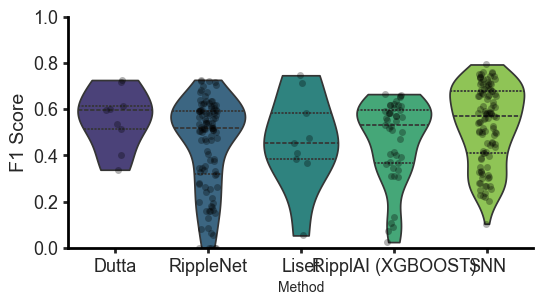

In [9]:
def plot_comparison_by_thresholds(config, metric="F1", reference_method="SNN", sessions_reject=None):
    """
    Plots metric distribution for specific thresholds across different dataframes.
    
    Args:
        config (dict): Dictionary where key is the label (str) and value is a tuple (DataFrame, threshold_value).
                       Example: {"Dutta": (dutta_df, 0.6), "SNN": (snn_df, 0.4)}
        metric (str): Metric to plot (default "F1").
        reference_method (str): Method to compare others against (default "SNN").
        sessions_reject (set/list): Optional set of session IDs to exclude.
    """
    combined_data = []
    
    for label, (df, threshold) in config.items():
        
        # Filter sessions if requested
        if sessions_reject is not None:
            df = df[~df["Session"].isin(sessions_reject)]
            
        print("Number of sessions in", label, ":", df["Session"].nunique())

        # Determine column name dynamically to avoid KeyError
        if "Threshold" in df.columns:
            col_name = "Threshold"
        elif "Adapt" in df.columns:
            col_name = "Adapt"
        else:
            print(f"Skipping {label}: Neither 'Threshold' nor 'Adapt' column found.")
            continue

        # Filter for the specific threshold
        subset = df[df[col_name] == threshold].copy()
        
        if len(subset) == 0:
            print(f"Warning: No data found for '{label}' at {col_name} {threshold}. Available: {sorted(df[col_name].unique())}")
            continue
            
        subset["Method"] = label
        combined_data.append(subset)
    
    if not combined_data:
        print("No data available to plot.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    # Plot setup
    fig, ax = plt.subplots(figsize=(6, 3))
    order = list(config.keys())
    # Filter order to only include those that had data
    order = [o for o in order if o in plot_df["Method"].unique()]
    
    colors = sns.color_palette("viridis", len(order))
    # colors=["#f6fff8","#eaf4f4","#cce3de","#a4c3b2","#6b9080"]
    # Violin plot
    sns.violinplot(x="Method", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=order)
    sns.stripplot(x="Method", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=order)
    
    # Statistics (Paired Wilcoxon)
    # Pivot to align samples by Session/Channel for paired testing
    pivot_cols = ["Session", "Channel"]
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Method", values=metric)
    
    # Annotate medians
    medians = plot_df.groupby('Method')[metric].median()
    mins = plot_df.groupby('Method')[metric].min()
    
    for i, method in enumerate(order):
        if method in medians:
            val = medians[method]
            min_val = mins[method]
            # Position text slightly below the minimum point
            # ax.text(i, min_val - 0.08, f'M={val:.2f}', ha='center', va='top', fontsize=11, color='black')

    # Statistical brackets - Only compare reference_method vs others
    if len(pivot) > 0 and reference_method in pivot.columns:
        centers = range(len(order))
        max_val = plot_df[metric].max()
        
        # Find index of reference method
        try:
            ref_idx = order.index(reference_method)
        except ValueError:
            print(f"Reference method {reference_method} not in plot order.")
            ref_idx = -1

        if ref_idx != -1:
            bracket_counter = 0
            
            # Iterate over other methods to compare against reference
            for i, method in enumerate(order):
                if method == reference_method:
                    continue
                
                if method not in pivot:
                    continue
        
                # Get paired data
                v1 = pivot[reference_method]
                v2 = pivot[method]
                
                # Align indices to ensure paired samples
                common = v1.index.intersection(v2.index)
                v1 = v1.loc[common]
                v2 = v2.loc[common]
                
                if len(v1) >= 3:
                    # Use Wilcoxon for paired samples (same session/channel)
                    stat, p = wilcoxon(v1, v2)
                    
                    if p < 0.05:
                        
                        # Stacking brackets
                        h = max_val + 0.01 + (bracket_counter * 0.08)
                        print(f"{reference_method} vs {method}: p={p:.4f}")
                        barplot_annotate_brackets(ref_idx, i, p, centers, [h]*len(centers), ax,barh=0,maxasterix=3)
                        bracket_counter += 1

    # Styling
    ax.set_ylim(0, 1.0) # Add space for brackets
    ax.set_ylabel(f"{metric} Score", fontsize=14)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)

# --- Example Usage ---
comparison_config = {
    "Dutta": (dutta_df, 6.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.5),
    "RipplAI (XGBOOST)": (ripplAI_df[ripplAI_df['Model']=='XGBOOST'], 0.5),
    "SNN": (snn_df,120)
}

if 'dutta_df' in locals():
    plot_comparison_by_thresholds(comparison_config, metric="F1", reference_method="SNN", sessions_reject=sessions_to_reject)

Number of sessions in Dutta : 9
Number of sessions in RippleNet : 9
Number of sessions in Liset : 9
Number of sessions in RipplAI (CNN1D) : 9
Number of sessions in SNN : 9
SNN vs Dutta: p=0.0078


C:\Users\Pc\AppData\Local\Temp\ipykernel_10044\3907588862.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Method", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=order)


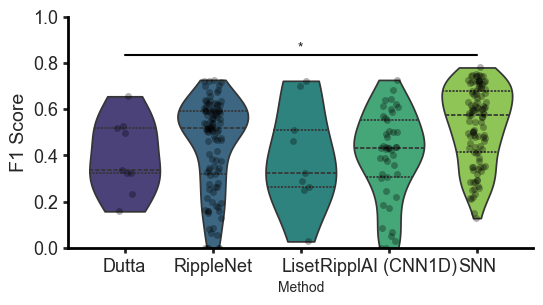

In [10]:
# Default Parameters

comparison_config = {
    "Dutta": (dutta_df, 4.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.7),
    "RipplAI (CNN1D)": (ripplAI_df[ripplAI_df['Model']=='CNN1D'], 0.3),
    "SNN": (snn_df,20)
}

if 'dutta_df' in locals():
    plot_comparison_by_thresholds(comparison_config, metric="F1", reference_method="SNN", sessions_reject=sessions_to_reject)

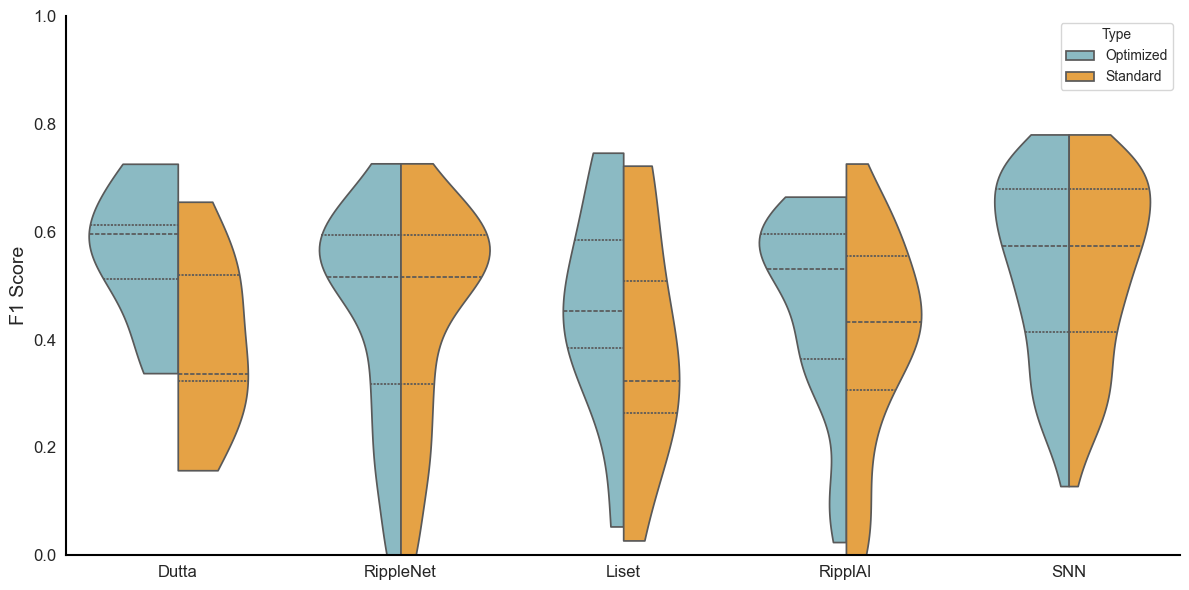

In [11]:
def plot_comparison_split_violin(config_opt, config_std, metric="F1", reference_method="SNN", sessions_reject=None):
    """
    Plots split violins comparing two configurations (e.g. Optimized vs Standard).
    """
    combined_data = []

    def process_config(config, type_label):
        for label, (df, threshold) in config.items():
            # Filter sessions
            if sessions_reject is not None:
                df_subset = df[~df["Session"].isin(sessions_reject)].copy()
            else:
                df_subset = df.copy()

            # Identify column
            if "Threshold" in df_subset.columns:
                col = "Threshold"
            elif "Adapt" in df_subset.columns:
                col = "Adapt"
            else:
                print(f"Skipping {label}: Column not found.")
                continue
                
            # Filter threshold
            subset = df_subset[df_subset[col] == threshold].copy()
            if len(subset) > 0:
                subset["Method"] = label
                subset["Type"] = type_label
                combined_data.append(subset)
            else:
                print(f"Warning: No data for {label} ({type_label}) at {threshold}")

    process_config(config_opt, "Optimized")
    process_config(config_std, "Standard")
    
    if not combined_data:
        print("No data to plot.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Determine order based on Optimized config keys
    order = [k for k in config_opt.keys() if k in plot_df["Method"].unique()]
    
    # Split Violin Plot
    sns.violinplot(x="Method", y=metric, hue="Type", data=plot_df, split=True, 
                   inner="quartile", palette={"Optimized": "#82C0CC", "Standard": "#FFA62B"}, 
                   ax=ax, order=order, cut=0)
    
    # --- Statistics (Optimized Set Only: Reference vs Others) ---
    # We focus stats on the "Optimized" set as it's likely the primary comparison
    opt_df = plot_df[plot_df["Type"] == "Optimized"]
    pivot = opt_df.pivot_table(index=["Session", "Channel"], columns="Method", values=metric)
    
    if len(pivot) > 0 and reference_method in pivot.columns:
        centers = range(len(order))
        max_val = plot_df[metric].max()
        
        try:
            ref_idx = order.index(reference_method)
        except ValueError:
            ref_idx = -1

        if ref_idx != -1:
            bracket_counter = 0
            for i, method in enumerate(order):
                if method == reference_method or method not in pivot:
                    continue
                
                # Paired Wilcoxon
                v1 = pivot[reference_method]
                v2 = pivot[method]
                common = v1.index.intersection(v2.index)
                v1, v2 = v1.loc[common], v2.loc[common]
                
                if len(v1) >= 3:
                    stat, p = wilcoxon(v1, v2)
                    if p < 0.05:
                        bracket_counter += 1
                        h = max_val + 0.05 + (bracket_counter * 0.08)
                        print(f"[Optimized] {reference_method} vs {method}: p={p:.4f}")
                        barplot_annotate_brackets(ref_idx, i, p, centers, [h]*len(centers), ax)

    ax.set_ylim(0, 1.4)
    ax.set_ylabel(f"{metric} Score", fontsize=14)
    ax.set_xlabel("")
    ax.legend(title="Parameters", loc='upper left', bbox_to_anchor=(1, 1))
    
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.5)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.show()

# --- Configuration ---

# 1. Optimized Parameters
config_opt = {
    "Dutta": (dutta_df, 6.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.5),
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='XGBOOST'], 0.5), # Renamed key to match
    "SNN": (snn_df, 120)
}

# 2. Standard/Default Parameters
config_std = {
    "Dutta": (dutta_df, 4.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.7),
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='CNN1D'], 0.3),   # Renamed key to match
    "SNN": (snn_df, 20)
}# filepath: c:\Users\Pc\Documents\Tese\LAVA_SNN_ripples\dutta_test\visualize_performance_all.ipynb
# ...existing code...
def plot_comparison_split_violin(config_opt, config_std, metric="F1", reference_method="SNN", sessions_reject=None):
    """
    Plots split violins comparing two configurations (e.g. Optimized vs Standard).
    """
    combined_data = []

    def process_config(config, type_label):
        for label, (df, threshold) in config.items():
            # Filter sessions
            if sessions_reject is not None:
                df_subset = df[~df["Session"].isin(sessions_reject)].copy()
            else:
                df_subset = df.copy()

            # Identify column
            if "Threshold" in df_subset.columns:
                col = "Threshold"
            elif "Adapt" in df_subset.columns:
                col = "Adapt"
            else:
                print(f"Skipping {label}: Column not found.")
                continue
                
            # Filter threshold
            subset = df_subset[df_subset[col] == threshold].copy()
            if len(subset) > 0:
                subset["Method"] = label
                subset["Type"] = type_label
                combined_data.append(subset)
            else:
                print(f"Warning: No data for {label} ({type_label}) at {threshold}")

    process_config(config_opt, "Optimized")
    process_config(config_std, "Standard")
    
    if not combined_data:
        print("No data to plot.")
        return

    plot_df = pd.concat(combined_data, ignore_index=True)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Determine order based on Optimized config keys
    order = [k for k in config_opt.keys() if k in plot_df["Method"].unique()]
    
    # Split Violin Plot
    sns.violinplot(x="Method", y=metric, hue="Type", data=plot_df, split=True, 
                   inner="quartile", palette={"Optimized": "#82C0CC", "Standard": "#FFA62B"}, 
                   ax=ax, order=order, cut=0)
    
    # --- Statistics (Optimized Set Only: Reference vs Others) ---
    # We focus stats on the "Optimized" set as it's likely the primary comparison
    opt_df = plot_df[plot_df["Type"] == "Optimized"]
    pivot = opt_df.pivot_table(index=["Session", "Channel"], columns="Method", values=metric)
    
    if len(pivot) > 0 and reference_method in pivot.columns:
        centers = range(len(order))
        max_val = plot_df[metric].max()
        
        try:
            ref_idx = order.index(reference_method)
        except ValueError:
            ref_idx = -1

        if ref_idx != -1:
            bracket_counter = 0
            for i, method in enumerate(order):
                if method == reference_method or method not in pivot:
                    continue
                
                # Paired Wilcoxon
                v1 = pivot[reference_method]
                v2 = pivot[method]
                common = v1.index.intersection(v2.index)
                v1, v2 = v1.loc[common], v2.loc[common]
                
                if len(v1) >= 3:
                    stat, p = wilcoxon(v1, v2)
                    if p < 0.05:
                        bracket_counter += 1
                        h = max_val + 0.05 + (bracket_counter * 0.08)
                        print(f"[Optimized] {reference_method} vs {method}: p={p:.4f}")
                        # barplot_annotate_brackets(ref_idx, i, p, centers, [h]*len(centers), ax)

    ax.set_ylim(0, 1)
    ax.set_ylabel(f"{metric} Score", fontsize=14)
    ax.set_xlabel("")
    # ax.legend(title="Parameters", loc='upper left', bbox_to_anchor=(1, 1))
    
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.5)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    plt.tight_layout()
    plt.show()

# --- Configuration ---

# 1. Optimized Parameters
config_opt = {
    "Dutta": (dutta_df, 6.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.5),
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='XGBOOST'], 0.5), # Renamed key to match
    "SNN": (snn_df, 20)
}

# 2. Standard/Default Parameters
config_std = {
    "Dutta": (dutta_df, 4.0),
    "RippleNet": (rippleNet_df, 0.7),
    "Liset": (liset_df, 0.7),
    "RipplAI": (ripplAI_df[ripplAI_df['Model']=='CNN1D'], 0.3),   # Renamed key to match
    "SNN": (snn_df, 20)
}

if 'dutta_df' in locals():
    plot_comparison_split_violin(config_opt, config_std, metric="F1", reference_method="SNN", sessions_reject=sessions_to_reject)

In [13]:
def get_summary_table(config_opt, config_std, sessions_reject=None):
    summary_data = []
    
    # List of metrics to check for in the dataframes
    metrics = ["F1", "Precision", "Recall"] 
    
    def process_config(config, type_label):
        for label, (df, threshold) in config.items():
            # Filter sessions
            if sessions_reject is not None:
                df_subset = df[~df["Session"].isin(sessions_reject)].copy()
            else:
                df_subset = df.copy()

            # Identify column for threshold
            if "Threshold" in df_subset.columns:
                col = "Threshold"
            elif "Adapt" in df_subset.columns:
                col = "Adapt"
            else:
                continue
                
            # Filter threshold
            subset = df_subset[df_subset[col] == threshold].copy()
            
            if len(subset) > 0:
                row = {
                    "Method": label,
                    "Type": type_label,
                    "Threshold": threshold
                }
                
                for m in metrics:
                    if m in subset.columns:
                        mean_val = subset[m].median()
                        std_val = subset[m].std()
                        # Format as Mean ± Std
                        row[f"{m}"] = f"{mean_val:.3f} ± {std_val:.3f}"
                    else:
                        row[f"{m}"] = "N/A"
                
                summary_data.append(row)

    process_config(config_opt, "Optimized")
    process_config(config_std, "Standard")
    
    summary_df = pd.DataFrame(summary_data)
    return summary_df

# Generate and display the table
if 'dutta_df' in locals() and 'config_opt' in locals():
    summary_table = get_summary_table(config_opt, config_std, sessions_reject=sessions_to_reject)
    print("Performance Summary Table:")
    display(summary_table)

Performance Summary Table:


,Method,Type,Threshold,F1,Precision,Recall
0,Dutta,Optimized,6.0,0.595 ± 0.130,0.581 ± 0.190,0.605 ± 0.126
1,RippleNet,Optimized,0.7,0.516 ± 0.199,0.551 ± 0.273,0.596 ± 0.286
2,Liset,Optimized,0.5,0.453 ± 0.207,0.694 ± 0.201,0.482 ± 0.233
3,RipplAI,Optimized,0.5,0.531 ± 0.174,0.463 ± 0.203,0.589 ± 0.212
4,SNN,Optimized,20.0,0.573 ± 0.168,0.564 ± 0.168,0.707 ± 0.243
5,Dutta,Standard,4.0,0.336 ± 0.161,0.230 ± 0.162,0.650 ± 0.049
6,RippleNet,Standard,0.7,0.516 ± 0.199,0.551 ± 0.273,0.596 ± 0.286
7,Liset,Standard,0.7,0.323 ± 0.225,0.875 ± 0.208,0.225 ± 0.199
8,RipplAI,Standard,0.3,0.432 ± 0.193,0.630 ± 0.284,0.380 ± 0.215
9,SNN,Standard,20.0,0.573 ± 0.168,0.564 ± 0.168,0.707 ± 0.243
